In [1]:
import glob
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Stimulus presentation offset derived from photodiode test
OFFSET = 0.015625

In [ ]:
""" 
Load localiser erp's
"""

loc_path = f"C:/Users/mvmigem/Documents/data/project_2/overlap_corrected/localiser/"
loc_dir_list = glob.glob(loc_path+'/*.csv')
loc_loaded_dfs = []

for p in loc_dir_list:
    df_sub = pd.read_csv(p)
    loc_loaded_dfs.append(df_sub)

df_loc = pd.concat(loc_loaded_dfs,ignore_index=True)
# Drop non EEG channels
df_loc = df_loc[~df_loc['channel'].isin(['eye_above','eye_below','eye_left','eye_right','Status'])]
max_time = .3 # change this depending on the ERP you want to look at
df_loc = df_loc[df_loc['time'] < max_time]

In [ ]:
""" 
Basline correction
"""
baseline_period = df_loc['time'] <0
baseline_means = df_loc[baseline_period].groupby(['subject','channel','position'])['yhat'].mean() #,'visual_field'

df_loc['baseline_corrected'] = df_loc.apply(
    lambda row: row['yhat'] - baseline_means[(row['subject'],row['channel'],row['position'])], #,row['visual_field']
    axis=1
)

In [ ]:
fig, ax = plt.subplots(1)
sns.lineplot(data=df_loc[df_loc['channel'] == "POz"],
            x='time',y='baseline_corrected',
            hue='position',
            errorbar='se')
ax.axhline(y=0, lw=1, c='black' )
ax.axvline(x=0.1, lw=1, c='black' )

In [2]:
""" 
Main data
"""
sub_path = "C:/Users/mvmigem/Documents/data/project_2/overlap_corrected/main/"
dir_list = glob.glob(sub_path+'/*.csv')
loaded_dfs = []
roi_channels = ['Oz','O1','O2',
                'PO3','POz','PO4',
                'P1','Pz','P2',
                'CP1','CPz','CP2',
                'PO8','PO7','P4','P3',
                'C5','C3','CP5','CP3',
                'C4','C6','CP4','CP6',
                ]
# roi_channels = ["Fz","FCz",
#                 "F1","F2",
#                 "FC1","FC2",
#                 "P1","Pz",
#                 "POz","P2",
#                 "Oz","PO3","PO4"] #P3b]

for p in dir_list:
    df_sub = pd.read_csv(p)
    df_sub = df_sub[df_sub['channel'].isin(roi_channels)]
    loaded_dfs.append(df_sub)

df = pd.concat(loaded_dfs,ignore_index=True)
# Drop non EEG channels
df = df[~df['channel'].isin(['eye_above','eye_below','eye_left','eye_right','Status'])]
max_time = .6 # change this depending on the ERP you want to look at
min_time = -.1
# correct for offset shift
df['time'] = df['time'] - OFFSET
df = df[df['time'] < max_time]
df = df[df['time'] > min_time]


In [ ]:
""" 
Baseline correction
"""
# df = df[df['sequence']==2]
df['visual_field'] = np.where(df['position'].isin([1, 2]), 'up', 'down')
baseline_period = df['time'] <0
baseline_means = df[baseline_period].groupby(['subject','channel','position','feature','attended_feature','unattended_feature'])['yhat'].mean() #,'visual_field'

df['y_bc'] = df.apply(
    lambda row: row['yhat'] - baseline_means[(row['subject'],row['channel'],row['position'],row['feature'],row['attended_feature'],row['unattended_feature'])],axis=1)


In [3]:
peak_prop_path = "C:/Users/mvmigem/Documents/data/project_2/compiled_data/c1_peak_properties.csv"
peak_prop = pd.read_csv(peak_prop_path)
best_pairs = list(zip(peak_prop['subject'], peak_prop['all_pos_peak_channel']))
df['selected_ch'] = df[['subject', 'channel']].apply(tuple, axis=1).isin(best_pairs)

In [4]:
# peak_prop['all_pos_peak_amplitude'].std() * 1e6
# peak_prop['all_pos_peak_latency'].std()
peak_prop['all_pos_peak_channel'].value_counts()

all_pos_peak_channel
POz    7
PO3    5
O2     5
CP1    4
O1     3
P2     2
Oz     2
P1     2
PO4    2
CP2    1
Name: count, dtype: int64

In [ ]:
df['abs_base'] = df['y_bc'].abs()
df['abs_norm'] = df['yhat'].abs()

### C1 plotting and extraction

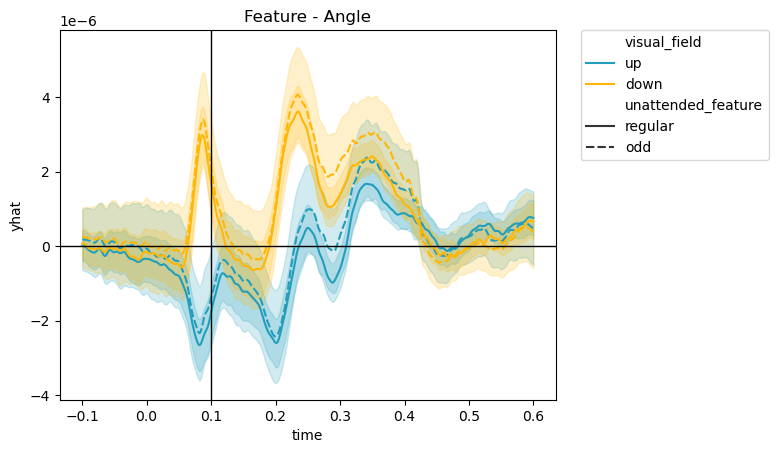

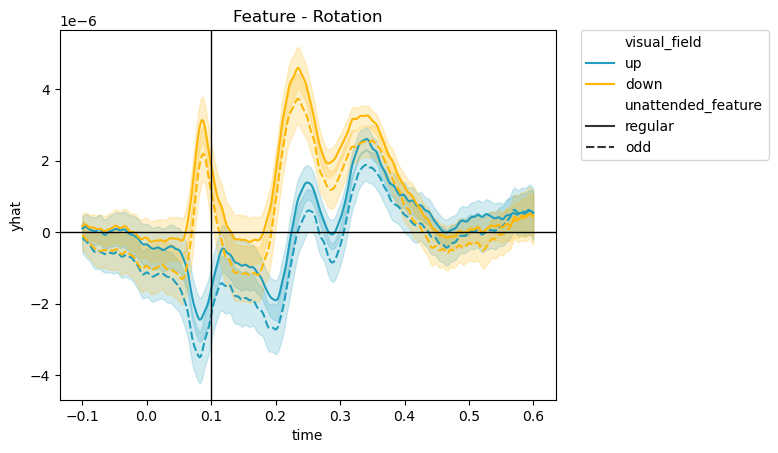

In [5]:
line_colours1= ['#219EBC','#FFB703']
line_colours2 = ['#8ECAE6','#FB8500',]
line_colours = ['#219EBC','#FFB703','#8ECAE6','#FB8500']

df = df[df['sequence']==2]
df['visual_field'] = np.where(df['position'].isin([1, 2]), 'up', 'down')
df_c1 = df[df['selected_ch']]


side = 'down'
y = 'yhat'

plt.subplots(1,1,sharey=False,sharex=False)

sns.lineplot(data=df_c1[df_c1['feature'] == 'angle'],
            x='time',y= y,
            hue='visual_field',style= 'unattended_feature',
            palette=line_colours1,
            errorbar='se')
# sns.lineplot(data=df_c1[df_c1['feature'] == 'angle'][df_c1['visual_field']=='down'],
#             x='time',y= y,
#             hue='attended_feature',style= 'unattended_feature',
#             palette=line_colours2,
#             errorbar='se')
plt.title("Feature - Angle")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.axhline(y=0, lw=1, c='black' )
plt.axvline(x=0.1, lw=1, c='black' )
plt.show()

plt.subplots(1,1,sharey=False,sharex=False)

sns.lineplot(data=df_c1[df_c1['feature'] == 'rotation'],
            x='time',y= y,
            hue='visual_field',style= 'unattended_feature',
            palette=line_colours1,
            errorbar='se')
# sns.lineplot(data=df_c1[df_c1['feature'] == 'rotation'][df_c1['visual_field']=='down'],
#             x='time',y= y,
#             hue='attended_feature',style= 'unattended_feature',
#             palette=line_colours2,
#             errorbar='se')
plt.title("Feature - Rotation")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.axhline(y=0, lw=1, c='black' )
plt.axvline(x=0.1, lw=1, c='black' )
plt.show()

# ax[1].axhline(y=0, lw=1, c='black' )
# ax[1].axvline(x=0.1, lw=1, c='black' )

In [8]:

# Separate conditions
unatt_reg_up_ang = df_c1[(df_c1['unattended_feature'] == 'regular') & 
                     (df_c1['feature'] == 'angle') &
                     (df_c1['visual_field'] == 'up')][['subject', 'time','yhat']]
unatt_odd_up_ang = df_c1[(df_c1['unattended_feature'] == 'odd') & 
                     (df_c1['feature'] == 'angle') &
                      (df_c1['visual_field'] == 'up')][['subject','time','yhat']]

unatt_reg_down_ang = df_c1[(df_c1['unattended_feature'] == 'regular') & 
                       (df_c1['feature'] == 'angle') &
                       (df_c1['visual_field'] == 'down')][['subject','time','yhat']]
unatt_odd_down_ang = df_c1[(df_c1['unattended_feature'] == 'odd' ) & 
                       (df_c1['feature'] == 'angle') &
                       (df_c1['visual_field'] == 'down')][['subject','time','yhat']]

# Merge and subtract
merged_unatt_up_ang = pd.merge(unatt_reg_up_ang, unatt_odd_up_ang, on=['subject', 'time'], suffixes=('_A', '_B'))
merged_unatt_up_ang['difference'] = merged_unatt_up_ang['yhat_A'] - merged_unatt_up_ang['yhat_B']

merged_unatt_down_ang = pd.merge(unatt_reg_down_ang, unatt_odd_down_ang, on=['subject', 'time'], suffixes=('_A', '_B'))
merged_unatt_down_ang['difference'] = merged_unatt_down_ang['yhat_A'] - merged_unatt_down_ang['yhat_B']

# c1_line_diff = c1_line[c1_line['feature'] =='rotation'].groupby(['subject','time']).agg()
merged_unatt_up_ang['visual_field'] = 'up'
merged_unatt_down_ang['visual_field'] = 'down'

merged_unatt_ang = pd.concat([merged_unatt_up_ang, merged_unatt_down_ang], ignore_index=True)
# Separate conditions
unatt_reg_up_rot = df_c1[(df_c1['unattended_feature'] == 'regular') & 
                     (df_c1['feature'] == 'rotation') &
                     (df_c1['visual_field'] == 'up')][['subject', 'time','yhat']]
unatt_odd_up_rot = df_c1[(df_c1['unattended_feature'] == 'odd') &
                    (df_c1['feature'] == 'rotation') &
                    (df_c1['visual_field'] == 'up')][['subject','time','yhat']]

unatt_reg_down_rot = df_c1[(df_c1['unattended_feature'] == 'regular') & 
                       (df_c1['feature'] == 'rotation') &
                       (df_c1['visual_field'] == 'down')][['subject','time','yhat']]
unatt_odd_down_rot = df_c1[(df_c1['unattended_feature'] == 'odd' ) & 
                       (df_c1['feature'] == 'rotation') &
                       (df_c1['visual_field'] == 'down')][['subject','time','yhat']]

# Merge and subtract
merged_unatt_up_rot = pd.merge(unatt_reg_up_rot, unatt_odd_up_rot, on=['subject', 'time'], suffixes=('_A', '_B'))
merged_unatt_up_rot['difference'] = merged_unatt_up_rot['yhat_A'] - merged_unatt_up_rot['yhat_B']

merged_unatt_down_rot = pd.merge(unatt_reg_down_rot, unatt_odd_down_rot, on=['subject', 'time'], suffixes=('_A', '_B'))
merged_unatt_down_rot['difference'] = merged_unatt_down_rot['yhat_A'] - merged_unatt_down_rot['yhat_B']
# c1_line_diff = c1_line[c1_line['feature'] =='rotation'].groupby(['subject','time']).agg()
merged_unatt_up_rot['visual_field'] = 'up'
merged_unatt_down_rot['visual_field'] = 'down'

merged_unatt_rot = pd.concat([merged_unatt_up_rot, merged_unatt_down_rot], ignore_index=True)

merged_unatt_rot['feature'] = 'rotation'
merged_unatt_ang['feature'] = 'angle'

merged_unatt = pd.concat([merged_unatt_rot, merged_unatt_ang], ignore_index=True)


In [7]:
# Separate conditions
att_reg_up_ang = df_c1[(df_c1['attended_feature'] == 'regular') & 
                     (df_c1['feature'] == 'angle') &
                     (df_c1['visual_field'] == 'up')][['subject', 'time','yhat']]
att_odd_up_ang = df_c1[(df_c1['attended_feature'] == 'odd') & 
                     (df_c1['feature'] == 'angle') &
                      (df_c1['visual_field'] == 'up')][['subject','time','yhat']]

att_reg_down_ang = df_c1[(df_c1['unattended_feature'] == 'regular') & 
                       (df_c1['feature'] == 'angle') &
                       (df_c1['visual_field'] == 'down')][['subject','time','yhat']]
att_odd_down_ang = df_c1[(df_c1['attended_feature'] == 'odd' ) & 
                       (df_c1['feature'] == 'angle') &
                       (df_c1['visual_field'] == 'down')][['subject','time','yhat']]

# Merge and subtract
merged_att_up_ang = pd.merge(att_reg_up_ang, att_odd_up_ang, on=['subject', 'time'], suffixes=('_A', '_B'))
merged_att_up_ang['difference'] = merged_att_up_ang['yhat_A'] - merged_att_up_ang['yhat_B']

merged_att_down_ang = pd.merge(att_reg_down_ang, att_odd_down_ang, on=['subject', 'time'], suffixes=('_A', '_B'))
merged_att_down_ang['difference'] = merged_att_down_ang['yhat_A'] - merged_att_down_ang['yhat_B']

# c1_line_diff = c1_line[c1_line['feature'] =='rotation'].groupby(['subject','time']).agg()
merged_att_up_ang['visual_field'] = 'up'
merged_att_down_ang['visual_field'] = 'down'

merged_att_ang = pd.concat([merged_att_up_ang, merged_att_down_ang], ignore_index=True)
# Separate conditions
att_reg_up_rot = df_c1[(df_c1['attended_feature'] == 'regular') & 
                     (df_c1['feature'] == 'rotation') &
                     (df_c1['visual_field'] == 'up')][['subject', 'time','yhat']]
att_odd_up_rot = df_c1[(df_c1['attended_feature'] == 'odd') &
                    (df_c1['feature'] == 'rotation') &
                    (df_c1['visual_field'] == 'up')][['subject','time','yhat']]

att_reg_down_rot = df_c1[(df_c1['attended_feature'] == 'regular') & 
                       (df_c1['feature'] == 'rotation') &
                       (df_c1['visual_field'] == 'down')][['subject','time','yhat']]
att_odd_down_rot = df_c1[(df_c1['attended_feature'] == 'odd' ) & 
                       (df_c1['feature'] == 'rotation') &
                       (df_c1['visual_field'] == 'down')][['subject','time','yhat']]

# Merge and subtract
merged_att_up_rot = pd.merge(att_reg_up_rot, att_odd_up_rot, on=['subject', 'time'], suffixes=('_A', '_B'))
merged_att_up_rot['difference'] = merged_att_up_rot['yhat_A'] - merged_att_up_rot['yhat_B']

merged_att_down_rot = pd.merge(att_reg_down_rot, att_odd_down_rot, on=['subject', 'time'], suffixes=('_A', '_B'))
merged_att_down_rot['difference'] = merged_att_down_rot['yhat_A'] - merged_att_down_rot['yhat_B']
# c1_line_diff = c1_line[c1_line['feature'] =='rotation'].groupby(['subject','time']).agg()
merged_att_up_rot['visual_field'] = 'up'
merged_att_down_rot['visual_field'] = 'down'

merged_att_rot = pd.concat([merged_att_up_rot, merged_att_down_rot], ignore_index=True)

merged_att_rot['feature'] = 'rotation'
merged_att_ang['feature'] = 'angle'

merged_att = pd.concat([merged_att_rot, merged_att_ang], ignore_index=True)


In [9]:
merged_att['feature_contrast'] = 'attended_feature'
merged_unatt['feature_contrast'] = 'unattended_feature'

merged = pd.concat([merged_att, merged_unatt], ignore_index=True)

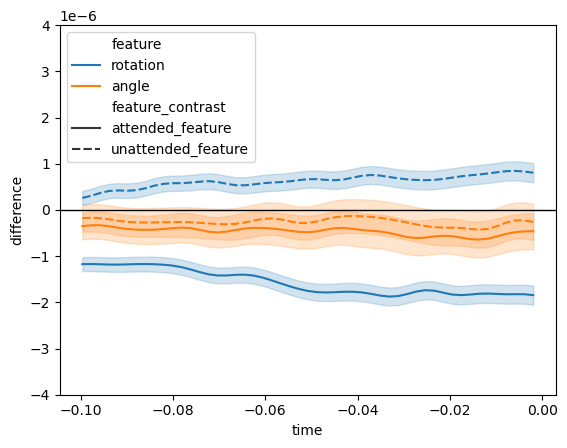

In [11]:
fig, ax = plt.subplots(1,1,sharey=False,sharex=False)
ax.set_ylim(-4 *1e-6,4*1e-6)
sns.lineplot(data = merged[merged['time'] < 0], 
            y = 'difference', x = 'time',
            errorbar= ('se',1),
            hue = 'feature',
            style = 'feature_contrast',
            linewidth=1.5,
            ax=ax)

ax.axhline(y=0, lw=1, c='black' )
plt.show()

In [ ]:
# Save for plotting
output_path = f"C:/Users/mvmigem/Documents/data/project_2/plotting_df/c1_plotting.csv"
df_c1.to_csv(output_path)

In [ ]:
subject_list = df['subject'].unique()

In [ ]:
""" 
C1 Extraction
"""

# Window search
c1_tmin = 0.06
c1_tmax = 0.09
c1_timwid = 0.01
c1_sampwid = int(c1_timwid*512)

winidx_c1 = []

subject_list = df['subject'].unique()

indexes_peak = []
for sub in subject_list:
    sub_df = df_c1[df_c1['subject']== sub]
    peak_time = peak_prop[peak_prop['subject'] == sub]['all_pos_peak_latency'].iloc[0]
    peak_indx = np.array(sub_df[sub_df['time'] == peak_time].index)
    indexes_peak = np.concatenate([indexes_peak,peak_indx],axis=0)
# Select window around it
winidx_c1_n = []
for i, idx in enumerate(indexes_peak):
    win_li = np.arange(idx - c1_sampwid, idx + c1_sampwid +1)
    winidx_c1_n = np.concatenate([winidx_c1_n,win_li],axis=0)
winidx_c1.append(winidx_c1_n)

winidx_c1_1 = winidx_c1[0].astype(int)
# Apply to df
c1_win_df_1 = df_c1[df_c1.index.isin(winidx_c1_1)]
c1_win_df_1['peak_latency'] =  df_c1.loc[indexes_peak]['time']
c1_means_df_1 = c1_win_df_1.groupby(['subject',
                                    #'visual_field',
                                     'feature',
                                     'attended_feature',
                                     'unattended_feature'])[['y_bc','abs_base','peak_latency']].mean().reset_index()


In [ ]:

# Plot each column in a separate figure
for sub in subject_list:
    sub_df = df_c1[df_c1['subject']==sub]
    peak_lat = c1_win_df_1[c1_win_df_1['subject']==sub]['peak_latency'].iloc[0]
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=sub_df[sub_df['feature'] == 'rotation'][sub_df['visual_field']=='up'],
            x='time',y= y,
            hue='attended_feature',style= 'unattended_feature',
            palette=line_colours1,
            errorbar='se')
    sns.lineplot(data=sub_df[sub_df['feature'] == 'rotation'][sub_df['visual_field']=='down'],
            x='time',y= y,
            hue='attended_feature',style= 'unattended_feature',
            palette=line_colours2,
            errorbar='se')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.axhline(y=0, lw=1, c='black' )
    plt.axvline(x=0.1, lw=1, c='black' )
    plt.axvline(x=peak_lat, lw=1, c='black' )
    plt.show()

In [ ]:
sns.set_style('whitegrid')
sns.set_context("paper")

line_colours1= ['#219EBC','#FFB703','#8ECAE6','#FB8500',]

g = sns.catplot(data= c1_means_df_1[c1_means_df_1['visual_field']=='up'], y = 'y_bc', x = 'attended_feature',
            hue = 'unattended_feature', col = 'feature',
            kind = 'bar',
            edgecolor= 'black',
            errorbar='se',
            linewidth=0.7, 
            hue_order= ['regular', 'odd'],
            order= ['regular', 'odd'],
            palette=line_colours1)
g = sns.catplot(data= c1_means_df_1[c1_means_df_1['visual_field']=='down'], y = 'y_bc', x = 'attended_feature',
            hue = 'unattended_feature', col = 'feature',
            kind = 'bar',
            edgecolor= 'black',
            errorbar='se',
            linewidth=0.7, 
            hue_order= ['regular', 'odd'],
            order= ['regular', 'odd'],
            palette=line_colours2)

plt.show()

In [ ]:
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/c1_amp_full_trial.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/c1_amp.csv"
output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/c1_amp_collapsed.csv"
c1_means_df_1.to_csv(output_path)

### P1,N1 and P2 plotting and extraction

In [ ]:
df['visual_field'] = np.where(df['position'].isin([1, 2]), 'up', 'down')

# df_comp = df[df['channel'].isin(["PO7","PO3","O1","PO8","PO4","O2"])] # P1
# df_comp = df[df['channel'].isin(["PO7","PO3","O1","Oz","PO8","PO4","O2","POz"])] # P2
# df_comp = df[df['channel'].isin(["C4","CP4","C6","CP6","C5","CP5","C3","CP3"])] # N1
# df_comp = df[df['channel'].isin(["P1","Pz","POz","P2","Oz","PO3","PO4","P4","P3"])] #P3
# df_comp = df[df['channel'].isin(["Fz","FCz","F1","F2","FC1","FC2"])] #P3a
df_comp = df[df['channel'].isin(["P1","Pz","POz","P2","PO3","PO4"])] #P3b
# df_comp = df[df['channel'].isin(["POz","Oz","PO3","PO4","P4","P3","O1","O2"])] #N2

df_comp = df_comp.groupby(['subject',
                            'time',
                            # 'visual_field',
                            'feature',
                            'attended_feature',
                            'unattended_feature'])[['y_bc','abs_base',]].mean().reset_index()


In [ ]:
# Save for plotting
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/plotting_df/p1_plotting.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/plotting_df/n1_plotting.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/plotting_df/p2_plotting.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/plotting_df/n2_plotting.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/plotting_df/p3_plotting.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/plotting_df/p3a_plotting.csv"
output_path = f"C:/Users/mvmigem/Documents/data/project_2/plotting_df/p3b_plotting.csv"
df_comp.to_csv(output_path)

In [ ]:

line_colours1= ['#219EBC','#FFB703']
line_colours2 = ["#8EE6A1","#FB00C0",]

side = 'up'
y = 'y_bc'

plt.subplots(1,1,sharey=False,sharex=False)

# sns.lineplot(data=df_comp[df_comp['feature'] == 'angle'],
#             x='time',y= y,
#             hue='attended_feature',style= 'unattended_feature',
#             palette=line_colours1,
#             errorbar='se')
sns.lineplot(data=df_comp,
            x='time',y= y,
            hue='attended_feature',style= 'unattended_feature',
            palette=line_colours1,
            errorbar='se')

plt.title("Feature - Angle")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.axhline(y=0, lw=1, c='black' )
plt.axvline(x=0.1, lw=1, c='black' )
# plt.ylim(-2*1e-6, 4*1e-6)
plt.show()

plt.subplots(1,1,sharey=False,sharex=False)

sns.lineplot(data=df_comp[df_comp['feature'] == 'rotation'],
            x='time',y= y,
            hue='attended_feature',style= 'unattended_feature',
            palette=line_colours1,
            errorbar='se')

plt.title("Feature - Rotation")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.axhline(y=0, lw=1, c='black' )
plt.axvline(x=0.1, lw=1, c='black' )
# plt.ylim(-2*1e-6, 4*1e-6)
plt.show()


In [ ]:
subject_list = df['subject'].unique()
# # Window selection P1
# comp_tmin = 0.1
# comp_tmax = 0.15
# comp_timwid = 0.015
# comp_sampwid = int(comp_timwid*512)
# measure = 'y_bc'

# #  Window selection N1
# comp_tmin = 0.15
# comp_tmax = 0.2
# comp_timwid = 0.015
# comp_sampwid = int(comp_timwid*512)
# measure = 'y_bc'

# #  Window selection P2
# comp_tmin = 0.22
# comp_tmax = 0.27
# comp_timwid = 0.02
# comp_sampwid = int(comp_timwid*512)
# measure = 'y_bc'

# #  Window selection N2
# comp_tmin = 0.27
# comp_tmax = 0.33
# comp_timwid = 0.02
# comp_sampwid = int(comp_timwid*512)
# measure = 'y_bc'

# #  Window selection P3
# comp_tmin = 0.3
# comp_tmax = 0.5
# comp_timwid = 0.05
# comp_sampwid = int(comp_timwid*512)
# measure = 'y_bc'

# #  Window selection P3a
# comp_tmin = 0.3
# comp_tmax = 0.4
# comp_timwid = 0.05
# comp_sampwid = int(comp_timwid*512)
# measure = 'y_bc'

#  Window selection P3b
comp_tmin = 0.35
comp_tmax = 0.45
comp_timwid = 0.05
comp_sampwid = int(comp_timwid*512)
measure = 'y_bc'


In [ ]:
"""" 
ERP measure extraction
"""

# Select the place to search for peak
df_win = df_comp[(df_comp['time']>comp_tmin) & (df_comp['time']< comp_tmax )]

# Find time point in main df
indexes_peak =[]
for sub in subject_list:
    sub_df = df_win[df_win['subject'] == sub] 
    mean_window = sub_df.groupby(['time'])['y_bc'].mean().reset_index()
    peak_latency = mean_window.loc[mean_window['y_bc'].idxmax()]['time'] # All Positive ERP's
    # peak_latency = mean_window.loc[mean_window['y_bc'].idxmin()]['time'] # N1 and N2
# Find matching rows in df
    peak_indx = np.array(sub_df[
        (sub_df['time'] >= peak_latency - (1/512)) & 
        (sub_df['time'] <= peak_latency + (1/512))].index)
    indexes_peak = np.concatenate([indexes_peak,peak_indx],axis=0)
winidx = []
# Select window around it
for i, idx in enumerate(indexes_peak):
    win_li = np.arange(idx - comp_sampwid, idx + comp_sampwid +1)
    winidx.extend(win_li)

# Apply to df
# Apply to df
comp_win_df = df_comp[df_comp.index.isin(winidx)]
comp_win_df['peak_latency'] =  df_comp.loc[indexes_peak]['time']
comp_means_df = comp_win_df.groupby(['subject',
                                     'feature',
                                     'attended_feature',
                                     'unattended_feature'])[['y_bc','abs_base','peak_latency']].mean().reset_index()
# comp_means_df = comp_win_df.groupby(['subject',
#                                      'visual_field',
#                                      'feature',
#                                      'attended_feature',
#                                      'unattended_feature'])[['y_bc','abs_base','peak_latency']].mean().reset_index()

In [ ]:
# Plot individual erp's 
for sub in subject_list:
    sub_df = df_comp[df_comp['subject']==sub]
    peak_lat = comp_means_df[comp_means_df['subject']==sub]['peak_latency'].iloc[0]
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=sub_df[sub_df['feature'] == 'angle'],
            x='time',y= y,
            hue='attended_feature',style= 'unattended_feature',
            palette=line_colours1,
            errorbar='se')

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.axhline(y=0, lw=1, c='black' )
    plt.axvline(x=0.1, lw=1, c='black' )
    plt.axvline(x=peak_lat, lw=1, c='black' )
    plt.show()


In [ ]:
sns.set_style('whitegrid')
sns.set_context("paper")

line_colours1= ['#219EBC','#FFB703','#8ECAE6','#FB8500',]

g = sns.catplot(data= comp_means_df, y = 'y_bc', x = 'attended_feature',
            hue = 'unattended_feature', col = 'feature',
            kind = 'bar',
            edgecolor= 'black',
            errorbar='se',
            linewidth=0.7, 
            hue_order= ['regular', 'odd'],
            order= ['regular', 'odd'],
            palette=line_colours1)

plt.show()

In [ ]:
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/p3_amp.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/p3_amp_visual_field.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/p3_amp_visual_field_full_trial.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/p3a_amp.csv"
output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/p3b_amp.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/n2_amp.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/n2_amp_visual_field_full_trial.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/p2_amp.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/p2_amp_visual_field_full_trial.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/n1_amp.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/n1_amp_visual_field.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/n1_amp_visual_field_full_trial.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/p1_amp.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/p1_amp_visual_field.csv"
# output_path = f"C:/Users/mvmigem/Documents/data/project_2/compiled_data/p1_amp_visual_field_full_trial.csv"
comp_means_df.to_csv(output_path)

In [ ]:
check_data = "C:/Users/mvmigem/Documents/data/project_2/stimulus_effect_check.csv"
stimulus_check = pd.read_csv(check_data)
stimulus_check['subject'] = stimulus_check['participant']

In [ ]:
# Create a mapping dictionary from the shorter dataframe
angle_mapping = stimulus_check.set_index(['subject', 'feature', 'attended_feature', 'unattended_feature'])['angle'].to_dict()

# Map the values
df_comp['angle'] = df_comp.apply(
    lambda row: angle_mapping.get(
        (row['subject'], row['feature'], row['attended_feature'], row['unattended_feature']), 
        None
    ),
    axis=1
)
df_c1['angle'] = df_c1.apply(
    lambda row: angle_mapping.get(
        (row['subject'], row['feature'], row['attended_feature'], row['unattended_feature']), 
        None
    ),
    axis=1
)

In [ ]:

line_colours1= ['#219EBC','#FFB703']
line_colours2 = ["#8EE6A1","#FB00C0",]

side = 'up'
y = 'y_bc'

plt.subplots(1,1,sharey=False,sharex=False)

sns.lineplot(data=df_comp,
            x='time',y= y,
            hue='angle',
            palette=line_colours1,
            errorbar='se')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.axhline(y=0, lw=1, c='black' )
plt.axvline(x=0.1, lw=1, c='black' )
plt.ylim(-2*1e-6, 4*1e-6)
plt.show()


In [ ]:
line_colours1= ['#219EBC','#FFB703']
line_colours2 = ['#8ECAE6','#FB8500',]
plt.subplots(1,1,sharey=False,sharex=False)

sns.lineplot(data=df_c1[df_c1['visual_field']=='up'],
            x='time',y= y,
            hue='angle',
            palette=line_colours1,
            errorbar='se')
sns.lineplot(data=df_c1[df_c1['visual_field']=='down'],
            x='time',y= y,
            hue='angle',
            palette=line_colours2,
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.axhline(y=0, lw=1, c='black' )
plt.axvline(x=0.1, lw=1, c='black' )
plt.show()

In [ ]:
stimulus_check.value_counts(['angle', 'unattended_feature','feature'])